In [4]:
# ── Questions to Answer Prior Coding ────────────────────────────────────────────────
# 1. What is the clinical question this plot answers?

# Is a patient's level of consciousness linked to their blood pressure stability and
# do patients with lower GCS scares tend to also show dangerously low or extremly high
# blood pressure readings in the ER?

# 2. What type of plot is appropriate (histogram, scatter, bar, box)?

# A box plot would be more suited as GCS only takes numbers between 3-15. A boxplot for each
# GCS score and SBP readings will allow you to be able to see the median SBP, the spread, and the outliers.

# 3. What reference lines or annotations would add clinical meaning?

# 1. Sever Hypotension Threshold (< 90mmHG). Shown as a horizontal line and indicates that the patient is at risk of a circulatory shock.
# 2. Hypertension Threshold (> 180 mmHG). Shown as a horizontal line and marks dangerously high blood pressure.

In [2]:
# ── Importing Libraries and Mounting File Path ────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')
print("Drive Mounted")
FILE_PATH = '/content/drive/MyDrive/CARISURG/WEEK_0/EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive Mounted


In [3]:
# ── Cleaning all columns done from previous days ────────────────────────────────────────────────

# Gender Column
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# Glasglow Coma Scale (GCS)
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# Systolic Blood Pressure (SBP)
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# Diastolic Blood Pressure (DBP)
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temperature
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# Respiratory Rate (RR)
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# Fraction of Inspired Oxygen (FiO2)
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# Mean Arterial Pressure (MAP)
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


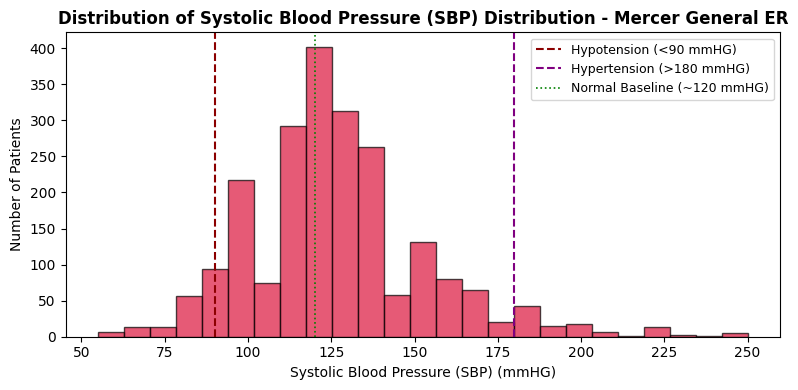

Saved: SBP_Histogram_Distribution.png


In [5]:
# ── Histogram for Systolic Blood Pressure Distributin ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))

# Creating the Histogram
ax.hist(df['SBP'], bins=25, edgecolor='black', color='crimson', alpha=0.7)

# Adding Clinical Reference Lines
ax.axvline(x=90, color='darkred', linestyle='--', linewidth=1.5, label='Hypotension (<90 mmHG)')

ax.axvline(x=180, color='purple', linestyle='--', linewidth=1.5, label='Hypertension (>180 mmHG)')

ax.axvline(x=120, color='green', linestyle=':', linewidth=1.2, label='Normal Baseline (~120 mmHG)')

# Styling the Histogram
ax.set_title('Distribution of Systolic Blood Pressure (SBP) Distribution - Mercer General ER', fontsize=12, fontweight='bold')
ax.set_xlabel('Systolic Blood Pressure (SBP) (mmHG)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('SBP_Histogram_Distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: SBP_Histogram_Distribution.png")


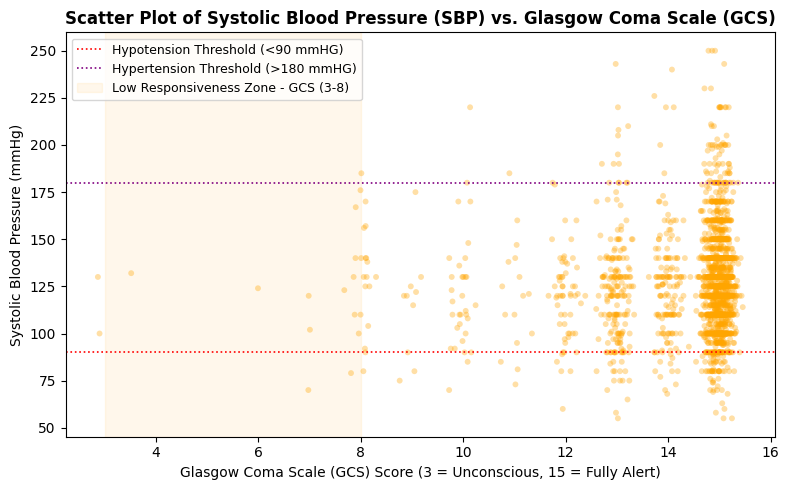

Saved: SBP_vs_GCS_Scatter.png


In [8]:
# ── Scatter Plot for SBP VS GCS ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

# Since GCS is a discrete integer scale (3-15), random 'jitters' were added to prevent overlapping
jitter = np.random.normal(0, 0.15, size=len(df))

scatter = ax.scatter(df['GCS'] + jitter, df['SBP'], alpha=0.35, s=18, color='orange', edgecolors='none')

# Adding threshold for SBP
ax.axhline(y=90, color='red', linestyle=':', linewidth=1.2, label='Hypotension Threshold (<90 mmHG)')
ax.axhline(y=180, color='purple', linestyle=':', linewidth=1.2, label='Hypertension Threshold (>180 mmHG)')

# Highlighting low GCS scores (3 to 8)
ax.axvspan(3, 8, alpha=0.08, color='orange', label='Low Responsiveness Zone - GCS (3-8)')

# Styling
ax.set_title ('Scatter Plot of Systolic Blood Pressure (SBP) vs. Glasgow Coma Scale (GCS)', fontsize=12, fontweight='bold')
ax.set_xlabel('Glasgow Coma Scale (GCS) Score (3 = Unconscious, 15 = Fully Alert)')
ax.set_ylabel('Systolic Blood Pressure (mmHg)')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('SBP_vs_GCS_Scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: SBP_vs_GCS_Scatter.png")

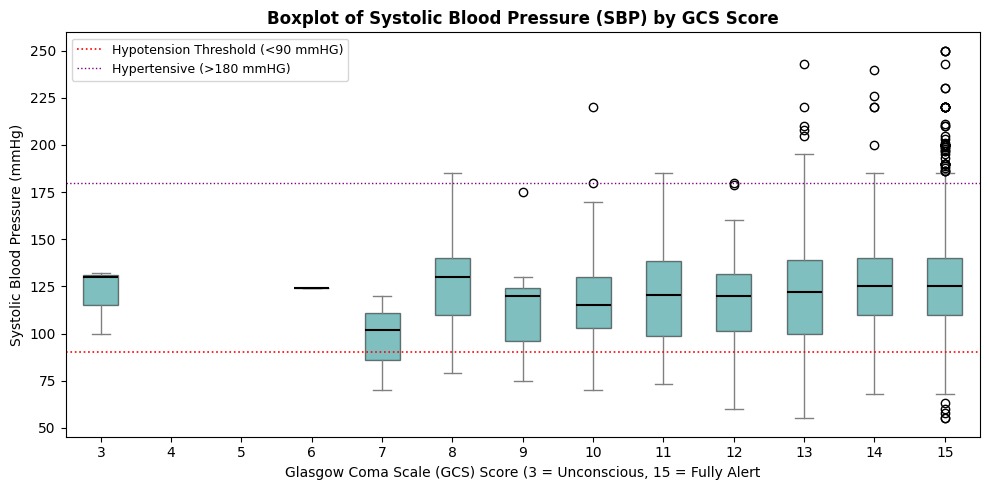

Saved: SBP_Boxplot_by_GCS.png


In [9]:
# ── Boxplot Plot for SBP grouped by individual GCS scores ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize = (10, 5))

# Separating SBP values into lists matching GCS scores from 3 to 15
gcs_groups = [df[df['GCS'] == g]['SBP'].dropna() for g in range(3, 16)]

# Drawing the Boxplots
ax.boxplot(gcs_groups, positions=range(3, 16), vert=True, patch_artist=True, boxprops=dict(facecolor='teal', alpha=0.5, edgecolor='black'), medianprops=dict(color='black', linewidth=1.5), whiskerprops=dict(color='gray'), capprops=dict(color='gray'))

# Adding Threshold
ax.axhline(y=90, color='red', linestyle=':', linewidth=1.2, label='Hypotension Threshold (<90 mmHG)')
ax.axhline(y=180, color='purple', linestyle=':', linewidth=1, label='Hypertensive (>180 mmHG)')

# Styling
ax.set_title('Boxplot of Systolic Blood Pressure (SBP) by GCS Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Glasgow Coma Scale (GCS) Score (3 = Unconscious, 15 = Fully Alert')
ax.set_ylabel('Systolic Blood Pressure (mmHg)')
ax.set_xticks(range(3, 16))
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('SBP_Boxplot_by_GCS.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: SBP_Boxplot_by_GCS.png")
#